# 01 — Exploration des données




In [1]:

# 0. IMPORTS


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


In [2]:

# 1. CHARGEMENT DES DONNÉES DEPUIS BIGQUERY


from google.cloud import bigquery


chemin_cle = "../credentials.json"

if Path(chemin_cle).exists():
    client = bigquery.Client.from_service_account_json(chemin_cle)
else:
    client = bigquery.Client(project="regal-unfolding-490222-g5")


def load_smartphone_data():
    queries = {
        "Amazon": """
            SELECT *
            FROM `regal-unfolding-490222-g5.dbt_price_intelligence_staging.stg_amazon`
        """,
        "Jumia": """
            SELECT *
            FROM `regal-unfolding-490222-g5.dbt_price_intelligence_staging.stg_jumia`
        """,
        "Electroplanet": """
            SELECT *
            FROM `regal-unfolding-490222-g5.dbt_price_intelligence_staging.stg_electroplanet`
        """
    }

    dataframes = []

    for site, sql in queries.items():
        print(f"Téléchargement des données de {site} en cours...")

        try:
            df_site = client.query(sql).to_dataframe()
            df_site["source_site"] = site
            dataframes.append(df_site)
            print(f"{site} : {len(df_site)} lignes récupérées.")

        except Exception as e:
            print(f"Erreur lors du chargement de {site} : {e}")

    if len(dataframes) == 0:
        raise ValueError("Aucune donnée n'a été chargée depuis BigQuery. Vérifie la connexion et les permissions.")

    df = pd.concat(dataframes, ignore_index=True)

    print("Fusion terminée avec succès.")
    print(f"Dimensions du dataset final : {df.shape}")

    return df


df = load_smartphone_data()

display(df.head())


Téléchargement des données de Amazon en cours...
Amazon : 183 lignes récupérées.
Téléchargement des données de Jumia en cours...
Jumia : 355 lignes récupérées.
Téléchargement des données de Electroplanet en cours...
Electroplanet : 71 lignes récupérées.
Fusion terminée avec succès.
Dimensions du dataset final : (609, 14)


,product_sk,name,brand,model,price,old_price,currency,discount,rating,reviews,url,source_site,scraped_at,scraped_date
0,b0a5de63adc90a330106ec34a9698ea8,SAMSUNG Galaxy A05s 4GB+64GB [Version Internat...,samsung,a05,146.59,NaN,EUR,NaN,4.4,28,,Amazon,2026-05-03 03:21:00.748826+00:00,2026-05-03
1,3eecd48ce5bb614fb07937a9aeb8f652,"Samsung Galaxy A07 LTE, Smartphone Android, 12...",samsung,a07,113.71,NaN,EUR,NaN,4.3,107,,Amazon,2026-05-03 03:21:17.177568+00:00,2026-05-03
2,fcb52728b59e12f8b0c36e963d0263c7,Smartphone Samsung Galaxy A15 128Go Bleu Noir 5G,samsung,a15,176.99,NaN,EUR,NaN,4.2,3,,Amazon,2026-05-03 03:20:58.315640+00:00,2026-05-03
3,9d4f5fd3e4028eabcb3cb630161f331d,Samsung Galaxy A16 5G Smartphone 128 GB Mitter...,samsung,a16,173.19,NaN,EUR,NaN,4.2,11,,Amazon,2026-05-03 03:21:01.224370+00:00,2026-05-03
4,216571865a76b7c8971659ecef718f6f,Samsung Galaxy A16 4GB+128GB [Version Internat...,samsung,a16,122.90,NaN,EUR,NaN,4.4,47,,Amazon,2026-05-03 03:21:15.059568+00:00,2026-05-03


In [3]:

# 2. VÉRIFICATION INITIALE DU DATASET


if df.empty:
    raise ValueError("Le DataFrame est vide. Vérifie la connexion BigQuery et les requêtes SQL.")

print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

print("\nColonnes disponibles :")
print(df.columns.tolist())

print("\nAperçu des premières lignes :")
display(df.head())

Nombre de lignes : 609
Nombre de colonnes : 14

Colonnes disponibles :
['product_sk', 'name', 'brand', 'model', 'price', 'old_price', 'currency', 'discount', 'rating', 'reviews', 'url', 'source_site', 'scraped_at', 'scraped_date']

Aperçu des premières lignes :


,product_sk,name,brand,model,price,old_price,currency,discount,rating,reviews,url,source_site,scraped_at,scraped_date
0,b0a5de63adc90a330106ec34a9698ea8,SAMSUNG Galaxy A05s 4GB+64GB [Version Internat...,samsung,a05,146.59,NaN,EUR,NaN,4.4,28,,Amazon,2026-05-03 03:21:00.748826+00:00,2026-05-03
1,3eecd48ce5bb614fb07937a9aeb8f652,"Samsung Galaxy A07 LTE, Smartphone Android, 12...",samsung,a07,113.71,NaN,EUR,NaN,4.3,107,,Amazon,2026-05-03 03:21:17.177568+00:00,2026-05-03
2,fcb52728b59e12f8b0c36e963d0263c7,Smartphone Samsung Galaxy A15 128Go Bleu Noir 5G,samsung,a15,176.99,NaN,EUR,NaN,4.2,3,,Amazon,2026-05-03 03:20:58.315640+00:00,2026-05-03
3,9d4f5fd3e4028eabcb3cb630161f331d,Samsung Galaxy A16 5G Smartphone 128 GB Mitter...,samsung,a16,173.19,NaN,EUR,NaN,4.2,11,,Amazon,2026-05-03 03:21:01.224370+00:00,2026-05-03
4,216571865a76b7c8971659ecef718f6f,Samsung Galaxy A16 4GB+128GB [Version Internat...,samsung,a16,122.90,NaN,EUR,NaN,4.4,47,,Amazon,2026-05-03 03:21:15.059568+00:00,2026-05-03


In [4]:

# 3. INFORMATIONS GÉNÉRALES


df.info()


<class 'pandas.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   product_sk    609 non-null    str                
 1   name          609 non-null    str                
 2   brand         609 non-null    str                
 3   model         609 non-null    str                
 4   price         609 non-null    float64            
 5   old_price     246 non-null    float64            
 6   currency      609 non-null    str                
 7   discount      226 non-null    str                
 8   rating        293 non-null    float64            
 9   reviews       255 non-null    Int64              
 10  url           609 non-null    str                
 11  source_site   609 non-null    str                
 12  scraped_at    609 non-null    datetime64[us, UTC]
 13  scraped_date  609 non-null    dbdate             
dtypes: Int64(1), datetime

In [5]:

# 4. DESCRIPTION DES COLONNES


dict_desc = {
    "product_sk": "Identifiant unique du produit",
    "name": "Nom du produit",
    "brand": "Marque du produit",
    "model": "Modèle du produit",
    "price": "Prix actuel affiché",
    "old_price": "Ancien prix avant réduction",
    "discount": "Montant ou pourcentage de réduction",
    "rating": "Note moyenne des utilisateurs",
    "reviews": "Nombre d'avis utilisateurs",
    "url": "Lien vers la page du produit",
    "source_site": "Plateforme source : Amazon, Jumia ou Electroplanet",
    "scraped_at": "Date et heure du scraping",
    "scraped_date": "Date du scraping"
}

column_description = pd.DataFrame({
    "Colonne": df.columns,
    "Description": [dict_desc.get(col, "Description à compléter") for col in df.columns]
})

display(column_description)


,Colonne,Description
0,product_sk,Identifiant unique du produit
1,name,Nom du produit
2,brand,Marque du produit
3,model,Modèle du produit
4,price,Prix actuel affiché
5,old_price,Ancien prix avant réduction
6,currency,Description à compléter
7,discount,Montant ou pourcentage de réduction
8,rating,Note moyenne des utilisateurs
9,reviews,Nombre d'avis utilisateurs


In [6]:

# 5. RAPPORT DE QUALITÉ DES DONNÉES


quality_report = pd.DataFrame({
    "Type": df.dtypes,
    "Valeurs uniques": df.nunique(),
    "Valeurs manquantes": df.isna().sum(),
    "% manquant": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values(by="% manquant", ascending=False)

print("Rapport de qualité des données :")
display(quality_report)


Rapport de qualité des données :


,Type,Valeurs uniques,Valeurs manquantes,% manquant
discount,str,46,383,62.89
old_price,float64,118,363,59.61
reviews,Int64,108,354,58.13
rating,float64,20,316,51.89
name,str,598,0,0.00
product_sk,str,609,0,0.00
price,float64,388,0,0.00
model,str,44,0,0.00
brand,str,3,0,0.00
currency,str,3,0,0.00


In [7]:

# 6. VÉRIFICATION DES DOUBLONS


nb_doublons = df.duplicated().sum()

print(f"Nombre de lignes parfaitement dupliquées : {nb_doublons}")

if nb_doublons > 0:
    print("\nAperçu de quelques doublons :")
    display(df[df.duplicated(keep=False)].head())
else:
    print("Aucun doublon parfait détecté.")

Nombre de lignes parfaitement dupliquées : 0
Aucun doublon parfait détecté.


In [8]:

# ANALYSE DÉTAILLÉE : COLONNES IMPORTANTES


colonnes_importantes = [
    "price",
    "old_price",
    "discount",
    "rating",
    "reviews",
    "brand",
    "source_site",
    "scraped_at"
]

print("Colonnes à analyser :")
print(colonnes_importantes)

Colonnes à analyser :
['price', 'old_price', 'discount', 'rating', 'reviews', 'brand', 'source_site', 'scraped_at']


In [9]:

# TYPES ET VALEURS MANQUANTES


for col in colonnes_importantes:
    
    if col in df.columns:
        print("\n" + "="*70)
        print(f"Analyse de la colonne : {col}")
        print("="*70)
        
        print(f"Type de donnée : {df[col].dtype}")
        
        missing_count = df[col].isna().sum()
        missing_pct = (missing_count / len(df)) * 100
        
        print(f"Valeurs manquantes : {missing_count} ({missing_pct:.2f}%)")
    
    else:
        print(f"\nLa colonne '{col}' n'existe pas dans le dataset.")


Analyse de la colonne : price
Type de donnée : float64
Valeurs manquantes : 0 (0.00%)

Analyse de la colonne : old_price
Type de donnée : float64
Valeurs manquantes : 363 (59.61%)

Analyse de la colonne : discount
Type de donnée : str
Valeurs manquantes : 383 (62.89%)

Analyse de la colonne : rating
Type de donnée : float64
Valeurs manquantes : 316 (51.89%)

Analyse de la colonne : reviews
Type de donnée : Int64
Valeurs manquantes : 354 (58.13%)

Analyse de la colonne : brand
Type de donnée : str
Valeurs manquantes : 0 (0.00%)

Analyse de la colonne : source_site
Type de donnée : str
Valeurs manquantes : 0 (0.00%)

Analyse de la colonne : scraped_at
Type de donnée : datetime64[us, UTC]
Valeurs manquantes : 0 (0.00%)


In [10]:

# STATISTIQUES DESCRIPTIVES DES COLONNES NUMÉRIQUES


for col in colonnes_importantes:
    
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        print("\n" + "="*70)
        print(f"Statistiques descriptives : {col}")
        print("="*70)
        
        display(df[col].describe().to_frame().T)


Statistiques descriptives : price


,count,mean,std,min,25%,50%,75%,max
price,609.0,4836.139491,5462.314566,7.09,709.0,2249.0,6990.0,20999.0



Statistiques descriptives : old_price


,count,mean,std,min,25%,50%,75%,max
old_price,246.0,8184.252033,7162.467836,59.0,1890.0,5590.0,13000.0,25499.0



Statistiques descriptives : rating


,count,mean,std,min,25%,50%,75%,max
rating,293.0,4.238908,0.664605,1.0,4.0,4.2,4.6,5.0



Statistiques descriptives : reviews


,count,mean,std,min,25%,50%,75%,max
reviews,255.0,96.85098,172.709103,1.0,3.0,22.0,93.0,997.0


In [11]:

# ANALYSE DES MARQUES


if "brand" in df.columns:
    print(f"Nombre de marques uniques : {df['brand'].nunique()}")
    print(f"Taux de valeurs manquantes : {round(df['brand'].isna().mean() * 100, 2)}%")

    print("\nTop 10 marques :")
    display(df["brand"].value_counts().head(10).to_frame("Nombre de produits"))

else:
    print("La colonne 'brand' n'existe pas dans ce dataset.")

Nombre de marques uniques : 3
Taux de valeurs manquantes : 0.0%

Top 10 marques :


,Nombre de produits
brand,
samsung,419
apple,187
other,3


In [12]:

#  RÉPARTITION PAR PLATEFORME

if "source_site" in df.columns:
    print("Répartition par plateforme :")
    display(df["source_site"].value_counts().to_frame("Nombre de produits"))

    print("\nRépartition en pourcentage :")
    display(
        (df["source_site"].value_counts(normalize=True) * 100)
        .round(2)
        .to_frame("Pourcentage (%)")
    )

else:
    print("La colonne 'source_site' n'existe pas dans ce dataset.")

Répartition par plateforme :


,Nombre de produits
source_site,
Jumia,355
Amazon,183
Electroplanet,71



Répartition en pourcentage :


,Pourcentage (%)
source_site,
Jumia,58.29
Amazon,30.05
Electroplanet,11.66


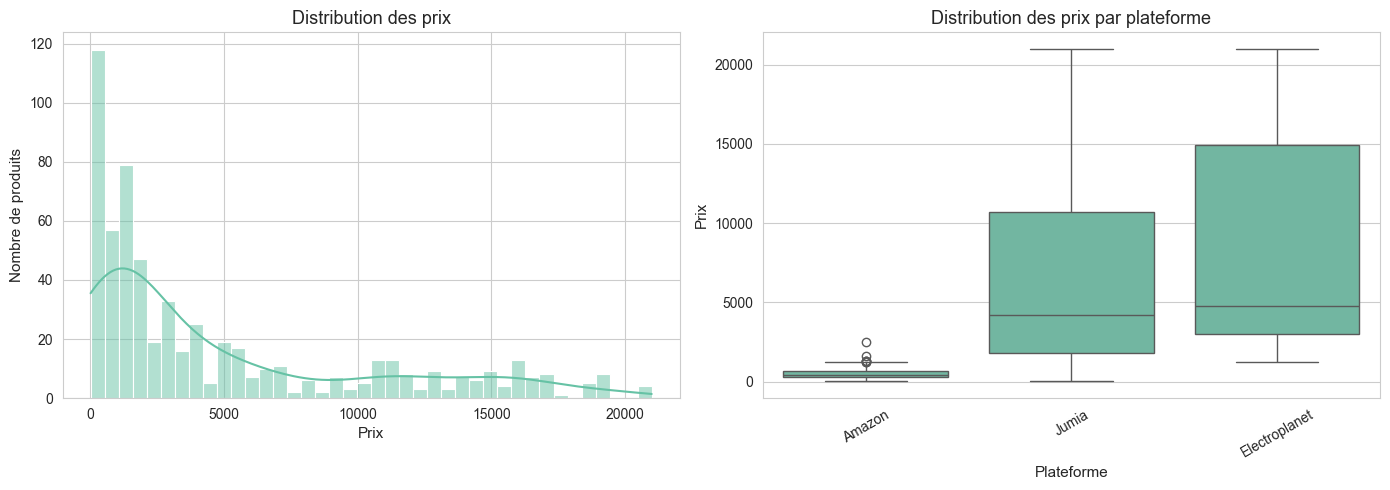

In [13]:

#  DISTRIBUTION DES PRIX


if "price" in df.columns:
    df_price = df.dropna(subset=["price"])

    if len(df_price) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.histplot(df_price["price"], bins=40, kde=True, ax=axes[0])
        axes[0].set_title("Distribution des prix")
        axes[0].set_xlabel("Prix")
        axes[0].set_ylabel("Nombre de produits")

        if "source_site" in df.columns:
            sns.boxplot(data=df_price, x="source_site", y="price", ax=axes[1])
            axes[1].set_title("Distribution des prix par plateforme")
            axes[1].set_xlabel("Plateforme")
            axes[1].set_ylabel("Prix")
            axes[1].tick_params(axis="x", rotation=30)
        else:
            axes[1].axis("off")
            axes[1].text(0.5, 0.5, "Colonne source_site absente", ha="center", va="center")

        plt.tight_layout()
        plt.show()
    else:
        print("La colonne price ne contient aucune valeur exploitable.")
else:
    print("La colonne 'price' n'existe pas dans ce dataset.")


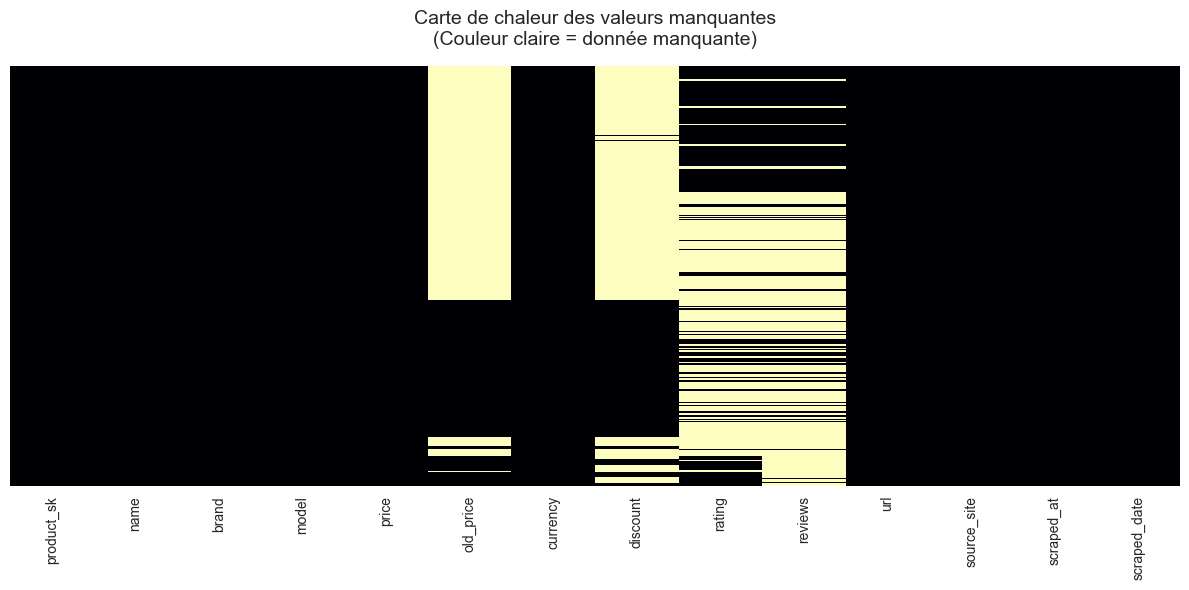

In [14]:

# CARTE DE CHALEUR DES VALEURS MANQUANTES


plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isna(),
    cbar=False,
    cmap="magma",
    yticklabels=False
)

plt.title(
    "Carte de chaleur des valeurs manquantes\n(Couleur claire = donnée manquante)",
    fontsize=14,
    pad=15
)

plt.tight_layout()
plt.show()


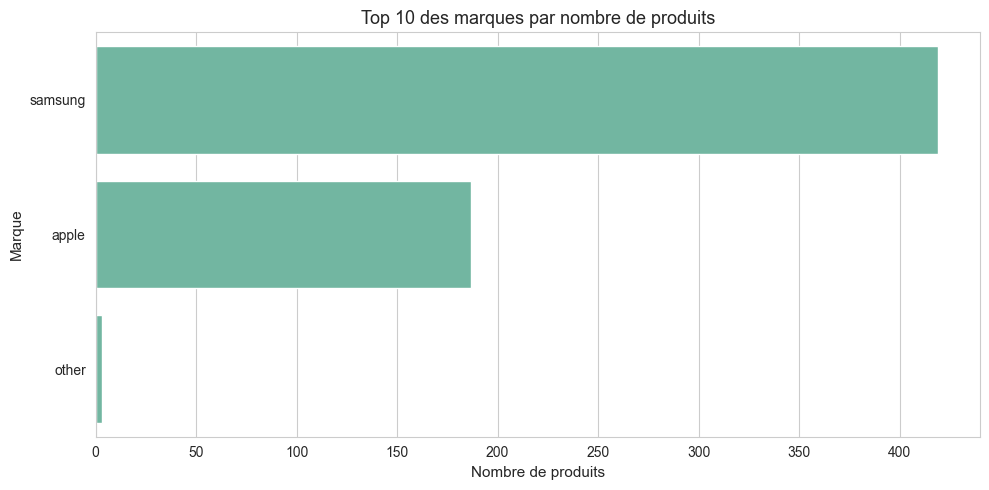

In [15]:

# . TOP 10 DES MARQUES


if "brand" in df.columns:
    top_brands = df["brand"].value_counts().head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_brands.values, y=top_brands.index)
    plt.title("Top 10 des marques par nombre de produits")
    plt.xlabel("Nombre de produits")
    plt.ylabel("Marque")
    plt.tight_layout()
    plt.show()
else:
    print("La colonne 'brand' n'existe pas dans ce dataset.")


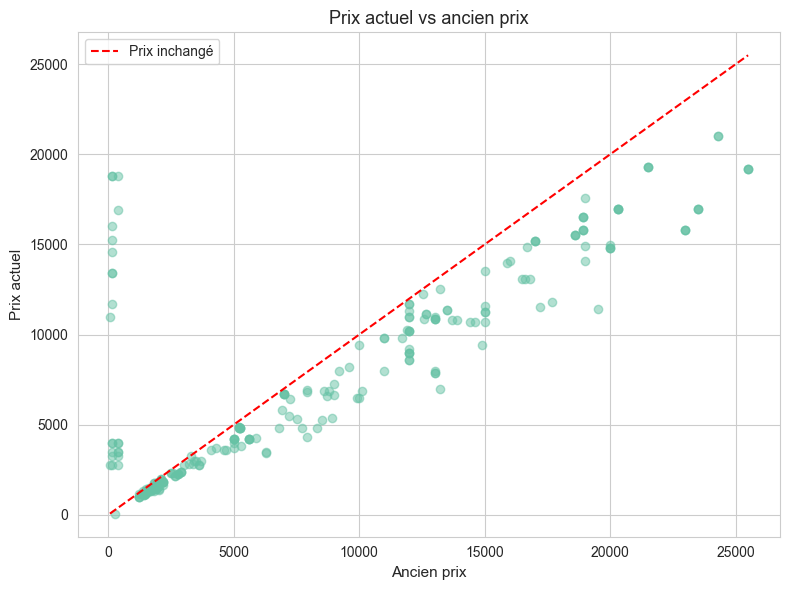

In [16]:

#  PRIX ACTUEL VS ANCIEN PRIX


if "price" in df.columns and "old_price" in df.columns:
    df_with_old = df.dropna(subset=["price", "old_price"]).copy()
    df_with_old["price"] = pd.to_numeric(df_with_old["price"], errors="coerce")
    df_with_old["old_price"] = pd.to_numeric(df_with_old["old_price"], errors="coerce")
    df_with_old = df_with_old.dropna(subset=["price", "old_price"])

    if len(df_with_old) > 10:
        plt.figure(figsize=(8, 6))
        plt.scatter(df_with_old["old_price"], df_with_old["price"], alpha=0.5)
        plt.plot(
            [df_with_old["old_price"].min(), df_with_old["old_price"].max()],
            [df_with_old["old_price"].min(), df_with_old["old_price"].max()],
            "r--",
            label="Prix inchangé"
        )
        plt.title("Prix actuel vs ancien prix")
        plt.xlabel("Ancien prix")
        plt.ylabel("Prix actuel")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Pas assez de données old_price pour produire ce graphique.")
else:
    print("Les colonnes 'price' et/ou 'old_price' sont absentes.")


In [17]:

#  NETTOYAGE MINIMAL DES DONNÉES


print(f"Lignes avant nettoyage : {len(df)}")

original_len = len(df)

df_before = df.copy()
df = df.drop_duplicates()
print(f"Doublons supprimés : {len(df_before) - len(df)}")

if "price" in df.columns:
    df["price"] = pd.to_numeric(df["price"], errors="coerce")

    df_before = df.copy()
    df = df.dropna(subset=["price"])
    print(f"Lignes sans prix supprimées : {len(df_before) - len(df)}")

    df_before = df.copy()
    df = df[df["price"] > 0]
    print(f"Lignes avec prix <= 0 supprimées : {len(df_before) - len(df)}")
else:
    print("La colonne 'price' est absente : nettoyage des prix non réalisé.")

if "scraped_at" in df.columns:
    df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce")
if "scraped_date" in df.columns:
    df["scraped_date"] = pd.to_datetime(df["scraped_date"], errors="coerce").dt.date

print(f"\nLignes après nettoyage : {len(df)}")

if original_len > 0:
    taux_retention = (len(df) / original_len) * 100
    print(f"Taux de rétention global : {taux_retention:.1f}%")


Lignes avant nettoyage : 609
Doublons supprimés : 0
Lignes sans prix supprimées : 0
Lignes avec prix <= 0 supprimées : 0

Lignes après nettoyage : 609
Taux de rétention global : 100.0%


In [18]:

#  SAUVEGARDE DU DATASET NETTOYÉ

from pathlib import Path

output_dir = Path("../outputs/Les tableaux de synthèse")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "01_smartphones_cleaned.parquet"

df.to_parquet(output_path, index=False)

print(f"Terminé : {len(df)} lignes sauvegardées dans : {output_path}")


Terminé : 609 lignes sauvegardées dans : ..\outputs\Les tableaux de synthèse\01_smartphones_cleaned.parquet
